# **Quantitative Strategy for Institutional Portfolio Diversification** 

- Author: Pablo Clemente Hevia
- Date: March, 25th
- Context: Institutional Asset Management Strategy Review
---

## **Tasks**

1. Using the data available and using Python, find for each of the 15 commodities the **optimal future maturity** on the last day of each month. The output is a DataFrame showing, for each date and each commodity, which maturity is the optimal one.

2. Develop a **strategy** to invest in the 15 commodity futures, always holding only **one maturity per commodity**, which you selected in part 1, i.e. the optimal future maturity for each commodity. The strategy should **rebalance once a month on the last day of the month and allocate equal weights** to all commodities.
---

## **Abstract**

This notebook implements a systematic investment strategy across a **global universe of commodities**. The core methodology focuses on **optimizing the roll yield** by dynamically selecting contract maturities across the term structure. By employing an **adaptive 1/N equal-weighting framework**, the strategy seeks to mitigate the negative carry inherent in passive indices and provide a robust hedge against inflationary shocks.

---

## **Index**

1. Imports and Configuration
2. Data Loading using Paths
3. Task 1: Optimal Future Maturity 
    1. Calculating OI and Volume Notionals
    2. Implementing Liquidity Constraints
    3. Identify Rebalancing Dates
    4. Roll Yield Calculation
    5. Final Selection
4. Task 2: Strategy Implementation
    1. Preparing The Data
    2. Returns, Weights and Performance
    3. Final Risk and Return profile
---

### 1. Imports and Configuration

This section initializes the analytical environment by importing core numerical libraries. We leverage the %autoreload extension to ensure seamless integration with the custom modular functions developed for this strategy.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [31]:
# We import the .py file with functions
%load_ext autoreload
%autoreload 2
import Wisdom_Tree_Case_Study_Functions as myfunctions

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

### 2. Data Loading using Paths

This section handles the ingestion of historical price series, contract specifications, and sector mappings. We implement explicit date parsing and path handling to ensure data integrity and notebook portability across different execution environments.

In [32]:
local_path = r'C:\Users\Pablo\OneDrive\Escritorio\WisdomTreeTask' # replace with the corresponding path
folder_path = local_path if os.path.exists(local_path) else os.getcwd()

print(f'Reading data from: {folder_path} ...')

# We upload the different files
prices_path = os.path.join(folder_path, 'contracts_prices.csv')
info_path = os.path.join(folder_path, 'contracts_info.csv')
sector_path = os.path.join(folder_path, 'sector_map.csv')

# We specify the format date for DD/MM/YYYY dates
prices = pd.read_csv(prices_path, parse_dates = ['date', 'last_trade_date'], dayfirst = True)
info = pd.read_csv(info_path)
sectors = pd.read_csv(sector_path)

print('Datasets loaded successfully.')

# Basic data audit
print('\nData information:')
print(f'Prices file: {prices.shape}')
print(f'Info file: {info.shape}')
print(f'Sectors file: {sectors.shape}')

Reading data from: C:\Users\Pablo\OneDrive\Escritorio\WisdomTreeTask ...
Datasets loaded successfully.

Data information:
Prices file: (942367, 8)
Info file: (74, 7)
Sectors file: (29, 3)


---

### 3. Task 1: Optimal Future Maturity

#### A. Calculating OI and Volume Notionals

In this section, we standardize the raw price data and calculate liquidity metrics in a common currency (USD). By merging contract specifications with historical prices, we derive the Notional Volume and Notional Open Interest (OI). This step is critical for ensuring that the strategy's signals are based on tradable, liquid instruments.

In [34]:
# First, we check for NULLs in volume and OI
print("\nNulls before cleaning:")
print(prices[['volume', 'oi']].isnull().sum())

# Clean: replace NaN/NULL with 0 (no trading activity for that specific maturity)
prices['volume'] = pd.to_numeric(prices['volume'], errors='coerce').fillna(0)
prices['oi'] = pd.to_numeric(prices['oi'], errors='coerce').fillna(0)

# Again after cleaning, we check for NULLs
print("\nNulls after cleaning:")
print(prices[['volume', 'oi']].isnull().sum())

# The normalize_prices function allow us to convert USd to USD, after merging the necessary information
prices_info = pd.merge(prices, info[['contract_code', 'contract_size', 'quote_currency']], on='contract_code', how='left')
prices_info_cleaned = myfunctions.normalize_prices(prices_info, 'price_usd', 'quote_currency', 'close')

# We now calculate notional volume and OI (price, contract size and volume/oi)
prices_info_cleaned['usd_volume'] = prices_info_cleaned['price_usd'] * prices_info_cleaned['contract_size'] * prices_info_cleaned['volume']
prices_info_cleaned['usd_oi'] = prices_info_cleaned['price_usd'] * prices_info_cleaned['contract_size'] * prices_info_cleaned['oi']

# Final check (NULLs)
print("\nNulls (final check):")
print(prices_info_cleaned[['usd_volume', 'usd_oi']].isnull().sum())

# We verify the math using some results 
cols_to_show = ['contract_code', 'quote_currency', 'price_usd', 'usd_volume', 'usd_oi']
print("\nFinal Sample:")
print(prices_info_cleaned[cols_to_show].head(10))
print(f'Rows in prices sample after cleaning: {len(prices_info_cleaned)}')


Nulls before cleaning:
volume    0
oi        0
dtype: int64

Nulls after cleaning:
volume    0
oi        0
dtype: int64

The normalize_prices function has been called. Prices quoted in USd has been converted to USD.

Nulls (final check):
usd_volume    0
usd_oi        0
dtype: int64

Final Sample:
  contract_code quote_currency  price_usd    usd_volume        usd_oi
0            SB            USd     0.1217  1.473310e+08  1.660169e+09
1            SB            USd     0.1261  1.205980e+08  1.495958e+09
2            SB            USd     0.1316  1.503693e+08  8.666944e+08
3            SI            USD    16.5030  2.595922e+08  1.854360e+09
4            SI            USD    16.8010  8.400500e+04  6.249972e+07
5            SI            USD    17.0560  8.528000e+04  1.705600e+05
6             W            USd     8.5025  1.193326e+09  4.702605e+09
7             W            USd     8.8200  1.323000e+07  2.959110e+07
8            CL            USD    87.1800  1.089750e+07  1.138571e+09
9

---

#### B. Implementing Liquidity Constraints

To ensure the strategy remains tradable for institutional-sized mandates, we implement strict liquidity thresholds. This section calculates a 22-business-day Rolling Average Daily Volume (ADV) and filters the universe based on two primary constraints:

1. Open Interest (OI): Minimum threshold of $100M USD to ensure deep market participation.

2. Average Daily Volume (ADV): Minimum threshold of $30M USD to mitigate market impact and execution slippage.

Contracts failing to meet these criteria are dynamically excluded from the investable universe.

In [35]:
# Sorting is essential for rolling window calculations to be chronologically accurate
prices_info_cleaned = prices_info_cleaned.sort_values(['contract_code', 'mat_year', 'mat_month', 'date'])

# Calculate the 1-month avg daily USD volume (grouping by contract, year and month)
days_window = 22 # 22-bussines-day window
prices_info_cleaned['avg_volume_1m'] = prices_info_cleaned.groupby(
    ['contract_code', 'mat_year', 'mat_month']
    )['usd_volume'].transform(lambda x: x.rolling(window=days_window, min_periods=1).mean())

print(prices_info_cleaned[['contract_code', 'mat_year', 'mat_month', 'avg_volume_1m']])

# Now we apply liquidity constraints:
    # 1) Open Interest OI >= $100M USD
    # 2) 1-Month Average Daily Volume (ADV) >= $30M USD
oi_constraint = 100e6
avg_vol_constraint = 30e6
liquid_contracts = prices_info_cleaned[(prices_info_cleaned['usd_oi'] >= oi_constraint) &
                                (prices_info_cleaned['avg_volume_1m'] >= avg_vol_constraint)].copy()

# Print the reduction in data to see how many contracts were filtered out
n_liquid_rows = len(liquid_contracts)
n_original_rows = len(prices_info_cleaned)
liquid_rate = round((n_liquid_rows/n_original_rows)*100,2)

print(f"\nOriginal rows: {n_original_rows}")
print(f"Liquid rows (OI > $100M & ADV > $30M): {n_liquid_rows}")
print(f"Eliminated rows by liquidity constraints: {n_original_rows - n_liquid_rows}, representing a {100 - liquid_rate}%")

print("\nLiquid Contracts Sample:")
print(liquid_contracts[['date', 'contract_code', 'mat_month', 'mat_year', 'usd_oi', 'avg_volume_1m']].head())

       contract_code  mat_year  mat_month  avg_volume_1m
1339               C      2008          3   2.620039e+09
1580               C      2008          3   2.441258e+09
1607               C      2008          3   2.377557e+09
3797               C      2008          3   2.272590e+09
3824               C      2008          3   2.333437e+09
...              ...       ...        ...            ...
936624            XB      2024          5   0.000000e+00
939452            XB      2024          5   0.000000e+00
939483            XB      2024          5   0.000000e+00
941774            XB      2024          5   0.000000e+00
941855            XB      2024          5   0.000000e+00

[942367 rows x 4 columns]

Original rows: 942367
Liquid rows (OI > $100M & ADV > $30M): 460168
Eliminated rows by liquidity constraints: 482199, representing a 51.17%

Liquid Contracts Sample:
           date contract_code  mat_month  mat_year        usd_oi  \
1339 2008-01-02             C          3      2008  1.

---

#### C. Identify Rebalancing Dates

To align the model with institutional execution standards, this section identifies the monthly rebalancing dates (typically the last business day of each month). We implement a 5-day safety buffer before the last trade date to ensure strategy tradability. This avoids the illiquidity and high volatility typical of expiry weeks and eliminates any potential physical delivery risk, making the backtest representative of real-world institutional execution.

In [38]:
# Create a copy to avoid modifying the source dataframe and ensure datetime format
df_safety = liquid_contracts.copy()
df_safety['date'] = pd.to_datetime(df_safety['date'])
df_safety['last_trade_date'] = pd.to_datetime(df_safety['last_trade_date'])

# Identify rebalancing dates
reb_dates = sorted(df_safety.groupby(df_safety['date'].dt.to_period('M'))['date'].max().unique())
# df_reb = liquid_contracts[liquid_contracts['date'].isin(reb_dates)].copy()

# Create the mapping 
next_reb_map = {reb_dates[i]: reb_dates[i+1] for i in range(len(reb_dates)-1)}
df_safety['next_rebalance_date'] = df_safety['date'].map(next_reb_map)
print('We expect only non NaT values for the rebalacing dates:')
print(df_safety[['date', 'next_rebalance_date']])

# Filter for rebalance days only
only_rebalance_days = df_safety[df_safety['next_rebalance_date'].notna()].copy()

# Operational Safety Buffer
safety_buffer = pd.Timedelta(days=5)
safe_universe = only_rebalance_days[
    only_rebalance_days['last_trade_date'] > (only_rebalance_days['next_rebalance_date'] + safety_buffer)
].copy()

# Check prints
print(f"\nOriginal liquid rows: {len(liquid_contracts)}")
print(f"Rebalance days rows:  {len(only_rebalance_days)}")
print(f"Safe universe rows:   {len(safe_universe)}")
print(f"Contracts removed:    {len(liquid_contracts) - len(safe_universe)}")

We expect only non NaT values for the rebalacing dates:
             date next_rebalance_date
1339   2008-01-02                 NaT
1580   2008-01-03                 NaT
1607   2008-01-04                 NaT
3797   2008-01-07                 NaT
3824   2008-01-08                 NaT
...           ...                 ...
934998 2022-03-31          2022-04-01
937040 2022-04-01                 NaT
940775 2022-03-25                 NaT
936047 2022-03-31          2022-04-01
936371 2022-04-01                 NaT

[460168 rows x 2 columns]

Original liquid rows: 460168
Rebalance days rows:  21560
Safe universe rows:   19754
Contracts removed:    440414


---

#### D. Roll Yield Calculation

This section implements the core quantitative signal of the strategy: the Implied Roll Yield. By comparing the price of the front-month contract against further maturities, we calculate the annualized cost of carry.

1. Backwardation (Positive Yield): Indicates a market in shortage, providing a tailwind for long positions.

2. Contango (Negative Yield): Represents a market in surplus, where "rolling" positions incurs a structural cost.

The calculation accounts for the time-to-maturity (month difference) to ensure all yields are comparable on an annualized basis.

In [39]:
# Apply the calculation for each commodity on each rebalancing date (using the roll yield function)
df_reb = safe_universe.groupby(['date', 'contract_code'], group_keys=False).apply(
    lambda x: myfunctions.calculate_roll_yield(x, 'mat_year', 'mat_month', 'price_usd')
)
print('\nThe calculate_roll_yield function has been called. The roll yield for the corresponding contracts has been calculated.')


The calculate_roll_yield function has been called. The roll yield for the corresponding contracts has been calculated.


In [41]:
# Quality check prints
print("-"*40)
print("Data quality check. Roll Yield:")
print("-"*40)
print(f"Total candidate contracts in safe universe: {len(df_reb)}")
roll_yield_nans = df_reb['roll_yield'].isna().sum()
print(f"NANs: {roll_yield_nans}")
# We check the average distance (this confirms month_diff is working)
avg_dist = df_reb['month_diff'].mean()
print(f"Average month distance from front: {avg_dist:.1f} months")

# Percentage of contracts in backwardation 
potential_trades = df_reb[df_reb['month_diff'] > 0]
if len(potential_trades) > 0:
    pos_yield = (potential_trades['roll_yield'] > 0).mean() * 100
    print(f"Contracts in backwardation (Yield > 0): {pos_yield:.2f}%")
else:
    print("No far-maturity contracts found to calculate backwardation.")

----------------------------------------
Data quality check. Roll Yield:
----------------------------------------
Total candidate contracts in safe universe: 19754
NANs: 0
Average month distance from front: 5.7 months
Contracts in backwardation (Yield > 0): 31.35%


---

**Example 1: CL (Oil) - Visualization**

To validate our selection logic, we visualize the Forward Curve for a specific commodity (e.g., Crude Oil and Natural Gas). This plots illustrate the relationship between contract maturity and price.

1. Dots: Individual futures contracts filtered by liquidity and safety buffers.

2. Labels: The annualized Roll Yield calculated for each segment relative to the front-month contract.

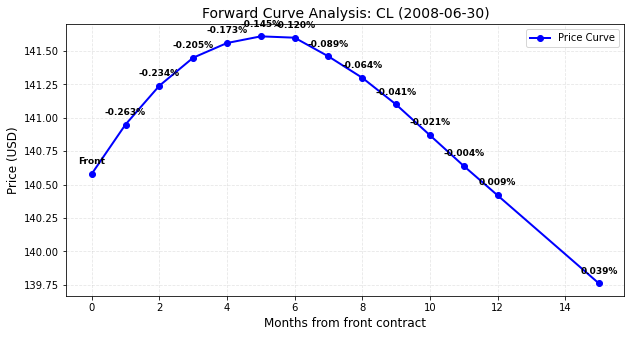

In [43]:
# Visualization (example for CL)
sample_date = reb_dates[5] # by changing the index we can easily see different curves!
commodity = 'CL'
curve_data_cl = df_reb[(df_reb['date'] == sample_date) & (df_reb['contract_code'] == commodity)].sort_values('month_diff')

# Plotting the curve
if not curve_data_cl.empty:
    plt.figure(figsize=(10, 5))
    plt.plot(curve_data_cl['month_diff'], curve_data_cl['price_usd'], marker='o', color='blue', linewidth=2, label='Price Curve')
    
    # Adding roll yield labels to each point
    for i, row in curve_data_cl.iterrows():
        label = "Front" if row['month_diff'] == 0 else f"{row['roll_yield']:.3%}"
        plt.annotate(label, 
                     (row['month_diff'], row['price_usd']),
                     textcoords="offset points", 
                     xytext=(0,10), 
                     ha='center', 
                     fontsize=9,
                     fontweight='bold')
    plt.title(f'Forward Curve Analysis: {commodity} ({pd.to_datetime(sample_date).date()})', fontsize=14)
    plt.xlabel('Months from front contract', fontsize=12)
    plt.ylabel('Price (USD)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.show()
else:
    print(f"No data found for {commodity} on {sample_date}")

**Example 2: NG (Natural Gas) - Visualization**

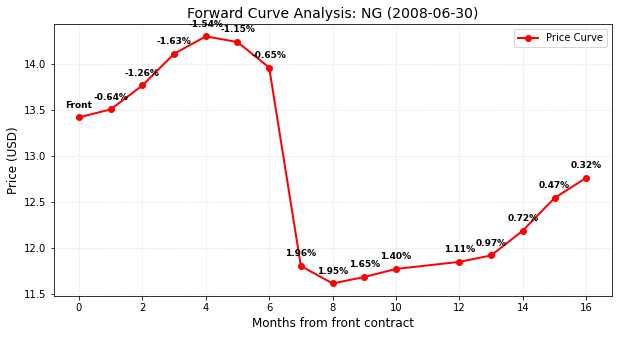

In [44]:
# Visualization (example for NG)
commodity = 'NG'
curve_data_ng = df_reb[(df_reb['date'] == sample_date) & (df_reb['contract_code'] == commodity)].sort_values('month_diff')

# Plotting the curve
if not curve_data_ng.empty:
    plt.figure(figsize=(10, 5))
    plt.plot(curve_data_ng['month_diff'], curve_data_ng['price_usd'], marker='o', color='red', linewidth=2, label='Price Curve')
    
    # Adding roll yield labels to each point
    for i, row in curve_data_ng.iterrows():
        label = "Front" if row['month_diff'] == 0 else f"{row['roll_yield']:.2%}"
        plt.annotate(label, 
                     (row['month_diff'], row['price_usd']),
                     textcoords="offset points", 
                     xytext=(0,10), 
                     ha='center', 
                     fontsize=9,
                     fontweight='bold')
    plt.title(f'Forward Curve Analysis: {commodity} ({pd.to_datetime(sample_date).date()})', fontsize=14)
    plt.xlabel('Months from front contract', fontsize=12)
    plt.ylabel('Price (USD)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.show()
else:
    print(f"No data found for {commodity} on {sample_date}")

---

#### E. Final Selection

This final section executes the selection logic. For each commodity and rebalancing date, the algorithm identifies the specific maturity that maximizes the Roll Yield.

In [21]:
# Highest Roll Yield for each date and each commodity
q1_selection = df_reb.loc[df_reb.groupby(['date', 'contract_code'])['roll_yield'].idxmax()].copy()

# Sort for clarity
q1_selection = q1_selection.sort_values(['date', 'contract_code'])

# Table to present
q1_output = q1_selection[['date', 'contract_code', 'mat_month', 'mat_year', 'roll_yield', 'month_diff']]
q1_output.columns = ['Rebalance_Date', 'Commodity', 'Opt_Mat_Month', 'Opt_Mat_Year', 'Max_Roll_Yield', 'Months_From_Front']

# Some checks
print("\nFinal Table: optimal maturities per month")
print("-"*50)
print(q1_output.head(20))
print(f"\nTotal selections: {len(q1_output)} rows")

# How many far contracts and front contracts we select?
front_picks = (q1_output['Months_From_Front'] == 0).sum()
far_picks = (q1_output['Months_From_Front'] > 0).sum()
print(f"\nSelections of front month: {front_picks}")
print(f"Selections of far maturities: {far_picks}")

# We calculate the average number of commodities selected per month (as a check)
print("\nAverage number of commodities selected per month:")
print(q1_output.groupby('Rebalance_Date')['Commodity'].count().mean())

# Export (required output for task 1)
q1_output.to_excel("Q1_Optimal_Contract_Selection.xlsx", index=False)
print('\nTask 1 completed. Optimal dataframe converted to excel file.')


Final Table: optimal maturities per month
--------------------------------------------------
      Rebalance_Date Commodity  Opt_Mat_Month  Opt_Mat_Year  Max_Roll_Yield  \
538       2008-01-31         C             12          2009        0.000553   
133       2008-01-31        CL              9          2008        0.002183   
134       2008-01-31        GC              4          2008        0.000000   
546       2008-01-31        HO              5          2008        0.009867   
1624      2008-01-31        KC              3          2008        0.000000   
1835      2008-01-31        LA              3          2008        0.000000   
2822      2008-01-31        LC              6          2008        0.004010   
1914      2008-01-31        LP             12          2009        0.002502   
2060      2008-01-31        LX             12          2009        0.001378   
2063      2008-01-31        NG              4          2008        0.000000   
1993      2008-01-31         S       

---

### 4. Task 2: Strategy Implementation

#### A. Preparing the Data

In this section, we transition from contract selection to Strategy Execution. We construct a systematic trading log by pairing each entry price with its corresponding exit price on the subsequent rebalancing date.

In [22]:
# Prepare by renaming some variables
portfolio_bt = q1_selection[['date', 'contract_code', 'mat_month', 'mat_year', 'price_usd']].copy()
portfolio_bt.columns = ['entry_date', 'commodity', 'mat_month', 'mat_year', 'price_entry']

# Map the exit date (the next rebalancing date in the sequence) and then merge
date_map = pd.DataFrame({
    'entry_date': reb_dates[:-1], 
    'exit_date': reb_dates[1:]
})
portfolio_bt = portfolio_bt.merge(date_map, on='entry_date')

# Fetch the exit price from the liquid universe
# We must match the exact same contract (code, month, year) at the next month's date
portfolio_bt = portfolio_bt.merge(
    liquid_contracts[['date', 'contract_code', 'mat_month', 'mat_year', 'price_usd']],
    left_on=['exit_date', 'commodity', 'mat_month', 'mat_year'],
    right_on=['date', 'contract_code', 'mat_month', 'mat_year'],
    how='inner'
).rename(columns={'price_usd': 'price_exit'}).drop(columns='date')

# Prints
print("\n" + "-"*60)
print(portfolio_bt[['commodity','entry_date', 'exit_date', 'price_entry', 'price_exit']].head(20))


------------------------------------------------------------
   commodity entry_date  exit_date  price_entry  price_exit
0          C 2008-01-31 2008-02-29      4.95500     5.38500
1         CL 2008-01-31 2008-02-29     90.69000   100.14000
2         GC 2008-01-31 2008-02-29    928.00000   975.00000
3         HO 2008-01-31 2008-02-29      2.48310     2.77540
4         LA 2008-01-31 2008-02-29   2695.25000  3076.00000
5         LC 2008-01-31 2008-02-29      0.93525     0.95325
6         LP 2008-01-31 2008-02-29   6985.00000  7722.00000
7         LX 2008-01-31 2008-02-29   2437.00000  2660.00000
8         NG 2008-01-31 2008-02-29      8.07400     9.36600
9          S 2008-01-31 2008-02-29     12.01500    13.71500
10        SB 2008-01-31 2008-02-29      0.12860     0.14620
11        SI 2008-01-31 2008-02-29     16.99500    19.80800
12         W 2008-01-31 2008-02-29      8.73500    10.00000
13        XB 2008-01-31 2008-02-29      2.27320     2.47540
14         C 2008-02-29 2008-03-31    

---

#### B. Returns, Weights and Performance

In this section, we aggregate individual contract returns into a consolidated portfolio performance. We adopt an equal-weight rebalancing scheme, allocating an identical notional weight to each selected commodity at the start of every month. This approach ensures diversification and prevents the strategy's performance from being skewed by a single commodity's idiosyncratic volatility.

1. Monthly Returns: Calculated as the simple price return between rebalancing dates.

2. Equity Curve: Represents the growth of a $1 initial investment, accounting for the monthly compounding effect of the strategy.


----------------------------------------
Strategy Performance Summary
----------------------------------------
Start Date:      2008-02-29
End Date:        2022-04-01
Final Multiplier: 1.1365x
Total Return:     13.65%
----------------------------------------

Observing the equity curve assuming 1$ as initial investment...


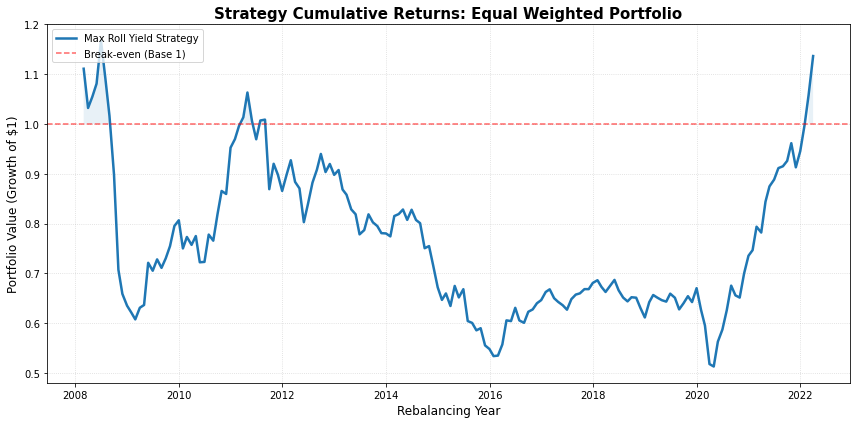


----------------------------------------
Weights Verification
----------------------------------------
   exit_date  commodity  individual_weight
0 2008-02-29         14           0.071429
1 2008-03-31         15           0.066667
2 2008-04-30         14           0.071429
3 2008-05-30         15           0.066667
4 2008-06-30         14           0.071429
5 2008-07-31         15           0.066667
6 2008-08-29         12           0.083333
7 2008-09-30         14           0.071429
8 2008-10-31         15           0.066667
9 2008-11-28         13           0.076923
----------------------------------------


In [24]:
# Simple returns calculation for each trade in the log
portfolio_bt['monthly_return'] = (portfolio_bt['price_exit'] / portfolio_bt['price_entry']) - 1

# Since we invest equally in all selected commodities, we take the simple mean
strategy_returns = portfolio_bt.groupby('exit_date')['monthly_return'].mean()

# Equity curve (growth of $1)
equity_curve = (1 + strategy_returns).cumprod()

# Summary report
print("\n" + "-"*40)
print("Strategy Performance Summary")
print("-"*40)
print(f"Start Date:      {equity_curve.index[0].date()}")
print(f"End Date:        {equity_curve.index[-1].date()}")
print(f"Final Multiplier: {equity_curve.iloc[-1]:.4f}x")
print(f"Total Return:     {(equity_curve.iloc[-1] - 1)*100:.2f}%")
print("-"*40)

# Plotting the equity curve
print('\nObserving the equity curve assuming 1$ as initial investment...')
plt.figure(figsize=(12, 6))
plt.plot(equity_curve.index, equity_curve.values, linewidth=2.5, label='Max Roll Yield Strategy')

# Adding visual aids
plt.axhline(y=1, color='red', linestyle='--', alpha=0.6, label='Break-even (Base 1)')
plt.fill_between(equity_curve.index, 1, equity_curve.values, where=(equity_curve.values > 1), alpha=0.1)
plt.title('Strategy Cumulative Returns: Equal Weighted Portfolio', fontsize=15, fontweight='bold')
plt.xlabel('Rebalancing Year', fontsize=12)
plt.ylabel('Portfolio Value (Growth of $1)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Some checks
weights_check = portfolio_bt.groupby('exit_date')['commodity'].count().reset_index()
weights_check['individual_weight'] = 1 / weights_check['commodity']
print("\n" + "-"*40)
print("Weights Verification")
print("-"*40)
print(weights_check.head(10))
print("-"*40)

---

**Performance Attribution by Commodity**

To understand the underlying drivers of the strategy, we decompose the total performance by individual asset. This granularity allows us to identify which commodities consistently benefit from the Roll Yield factor and assess the volatility profile of each position.


----------------------------------------
Return by Commodity (2008 - 2022)
----------------------------------------
    Total_Return_Pct  Annualized_Vol_Pct
XB        125.259200           32.970154
S         117.121605           21.692283
GC         64.542405           17.328034
LP         58.162554           23.902785
SI         55.533752           32.860702
LX         34.005420           25.829876
LC         -6.487001           14.127908
C         -11.365753           24.815000
LA        -26.604436           21.522765
HO        -34.041203           31.467162
SB        -37.192027           26.772534
W         -40.947200           33.228540
CL        -59.935788           38.546870
KC        -67.956297           28.599699
NG        -91.953908           32.710866
----------------------------------------


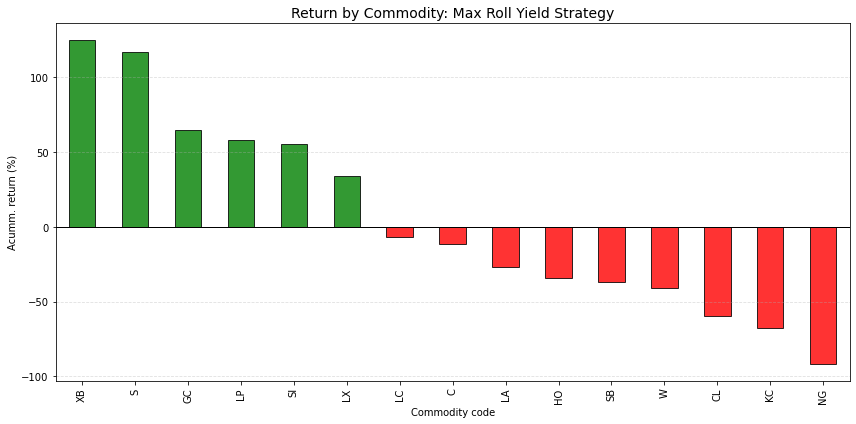

In [25]:
# We group by commodity, and then we multiply commodity's return
commodity_perf = portfolio_bt.groupby('commodity')['monthly_return'].apply(
    lambda x: (1 + x).prod() - 1
).sort_values(ascending=False)

# Annual volatility per commodity
commodity_vol = portfolio_bt.groupby('commodity')['monthly_return'].std() * (12**0.5)

# Results (ressume)
perf_by_comm = pd.DataFrame({
    'Total_Return_Pct': commodity_perf * 100,
    'Annualized_Vol_Pct': commodity_vol * 100
}).sort_values('Total_Return_Pct', ascending=False)

# Summary report
print("\n" + "-"*40)
print("Return by Commodity (2008 - 2022)")
print("-"*40)
print(perf_by_comm)
print("-"*40)

# Plot: winners vs. losers
plt.figure(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in perf_by_comm['Total_Return_Pct']]
perf_by_comm['Total_Return_Pct'].plot(kind='bar', color=colors, edgecolor='black', alpha=0.8)
plt.axhline(0, color='black', linewidth=1)
plt.title('Return by Commodity: Max Roll Yield Strategy', fontsize=14)
plt.ylabel('Acumm. return (%)')
plt.xlabel('Commodity code')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---

**Sector & Supersector Analysis**

To provide a comprehensive macro view, we aggregate the strategy’s performance into broader categories. By mapping individual commodities to their respective Sectors and Supersectors, we can identify the structural drivers of return across the resource landscape.

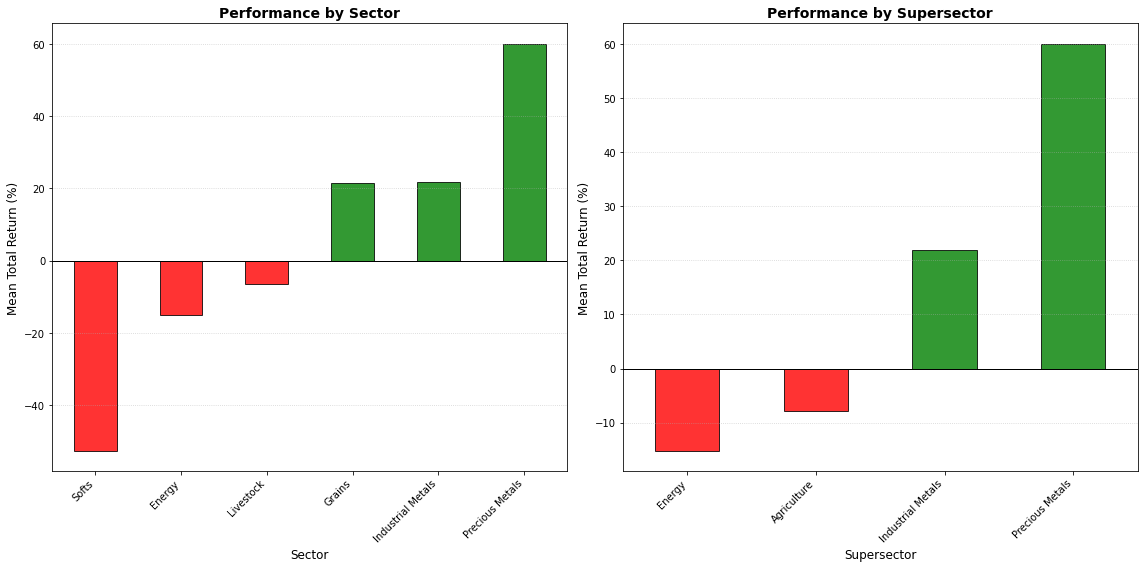

In [26]:
# We start with the performance by commodity
perf_to_merge = perf_by_comm.reset_index().rename(columns={'index': 'commodity'})

# We merge in order to obtain the name of the commodity using its contract code
df_with_names = perf_to_merge.merge(
    info[['contract_code', 'underlying_name']], 
    left_on='commodity', 
    right_on='contract_code', 
    how='left'
).rename(columns={'underlying_name': 'commodity_name'})

# We merge again to obtain sector and super sector of each commodity
df_final_attribution = df_with_names.merge(
    sectors[['commodity_name', 'commodity_sector', 'commodity_super_sector']], 
    on='commodity_name', 
    how='left'
)

# Finally, we group by sector and super sector
perf_sector = df_final_attribution.groupby('commodity_sector')['Total_Return_Pct'].mean().sort_values()
perf_super = df_final_attribution.groupby('commodity_super_sector')['Total_Return_Pct'].mean().sort_values()

# Plots
plt.figure(figsize=(16, 8))

# Subplot 1: Sector
plt.subplot(1, 2, 1)
colors_sec = ['red' if x < 0 else 'green' for x in perf_sector]
perf_sector.plot(kind='bar', color=colors_sec, edgecolor='black', alpha=0.8)
plt.title('Performance by Sector', fontsize=14, fontweight='bold')
plt.ylabel('Mean Total Return (%)', fontsize=12)
plt.xlabel('Sector', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Subplot 2: Supersector
plt.subplot(1, 2, 2)
colors_sup = ['red' if x < 0 else 'green' for x in perf_super]
perf_super.plot(kind='bar', color=colors_sup, edgecolor='black', alpha=0.8)
plt.title('Performance by Supersector', fontsize=14, fontweight='bold')
plt.ylabel('Mean Total Return (%)', fontsize=12)
plt.xlabel('Supersector', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

---

#### C. Final Risk and Return Profile

This final section quantifies the strategy's risk-adjusted profile. We calculate the Sharpe Ratio to measure excess return per unit of risk and the Maximum Drawdown to assess the peak-to-trough decline during the historical period.

In [27]:
# Annualized return (geometric mean)
total_months = len(strategy_returns)
annual_return = (equity_curve.iloc[-1]**(12/total_months)) - 1
total_return = equity_curve.iloc[-1] - 1

# Annualized volatility
annual_vol = strategy_returns.std() * (12**0.5)

# Sharpe Ratio: we define a constant annualized Risk-Free Rate of 3%
# This aims to represent a realistic average for 3-Month T-Bills over the 2008-2022 period
annual_rf = 0.03
sharpe_ratio = (annual_return - annual_rf) / annual_vol

# Max Drawdown
rolling_max = equity_curve.cummax()
drawdowns = (equity_curve / rolling_max) - 1
max_dd = drawdowns.min()

# Summary
print("\n" + "-"*40)
print("Strategy Final Metrics")
print("-"*40)
print(f"Annualized Return:    {annual_return*100:.2f}%")
print(f"Total Return:         {total_return:.2%}")
print(f"Annualized Vol:       {annual_vol*100:.2f}%")
print(f"Sharpe Ratio:         {sharpe_ratio:.2f}")
print(f"Max Drawdown:         {max_dd*100:.2f}%")


----------------------------------------
Strategy Final Metrics
----------------------------------------
Annualized Return:    0.90%
Total Return:         13.65%
Annualized Vol:       16.39%
Sharpe Ratio:         -0.13
Max Drawdown:         -56.07%


In [26]:
# Export (required output for task 2)
q2_output = equity_curve.to_frame(name='Strategy_Level')
q2_output['Monthly_Return_Pct'] = strategy_returns * 100
q2_output.index.name = 'Date'
q2_output = q2_output.reset_index()
q2_output.to_excel("Q2_Strategy_Backtest_Levels.xlsx", index=False)

print('\nTask 2 completed. Backtest levels for the strategy in Excel file.')


Task 2 completed. Backtest levels for the strategy in Excel file.


---

### Extra: Benchmark

The Bloomberg Commodity Index (BCOM) is the global standard used to measure the performance of the commodities market. It tracks a wide range of essential goods, such as energy, metals, and agriculture.

In [28]:
# We import the benchmark data
benchmark_path = os.path.join(folder_path, 'commodity_benchmark.csv')
benchmark_df = pd.read_csv(benchmark_path)
benchmark_df['Date'] = pd.to_datetime(benchmark_df['Date'])

# Data cleaning and return calculation: handling percentage strings from financial web providers
benchmark_df['Change %'] = (
    benchmark_df['Change %']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace(',', '.', regex=False)
)
benchmark_df['BCOM_Return'] = pd.to_numeric(benchmark_df['Change %']) / 100

# Ensuring data is sorted by date
benchmark_df = benchmark_df.sort_values('Date').reset_index(drop=True)
benchmark_equity = (1 + benchmark_df['BCOM_Return']).cumprod()

# Total months
total_months_bench = len(benchmark_df)

# Annualized Return
b_annual_return = (benchmark_equity.iloc[-1]**(12 / total_months_bench)) - 1
b_total_return = benchmark_equity.iloc[-1] - 1

# Annualized Volatility
b_annual_vol = benchmark_df['BCOM_Return'].std() * (12**0.5)

# Sharpe Ratio: we define a constant annualized Risk-Free Rate of 3%
# Again, this aims to represent a realistic average for 3-Month T-Bills over the 2008-2022 period
annual_rf = 0.03
b_sharpe_ratio = (b_annual_return - annual_rf) / b_annual_vol

# Maximum drawdown
b_rolling_max = benchmark_equity.cummax()
b_drawdowns = (benchmark_equity / b_rolling_max) - 1
b_max_dd = b_drawdowns.min()

# Summary report
print("\n" + "-"*40)
print("Benchmark Final Metrics: Bloomber Commodity Index (BCOM)")
print("-"*40)
print(f"Annualized Return:    {b_annual_return:.2%}")
print(f"Total Return:         {b_total_return:.2%}")
print(f"Annualized Vol:       {b_annual_vol:.2%}")
print(f"Sharpe Ratio:         {b_sharpe_ratio:.2f}")
print(f"Max Drawdown:         {b_max_dd:.2%}")
print("-"*40)


----------------------------------------
Benchmark Final Metrics: Bloomber Commodity Index (BCOM)
----------------------------------------
Annualized Return:    -3.54%
Total Return:         -39.94%
Annualized Vol:       16.78%
Sharpe Ratio:         -0.39
Max Drawdown:         -73.88%
----------------------------------------



Plotting BCOM Index Growth assuming $1 as initial investment...


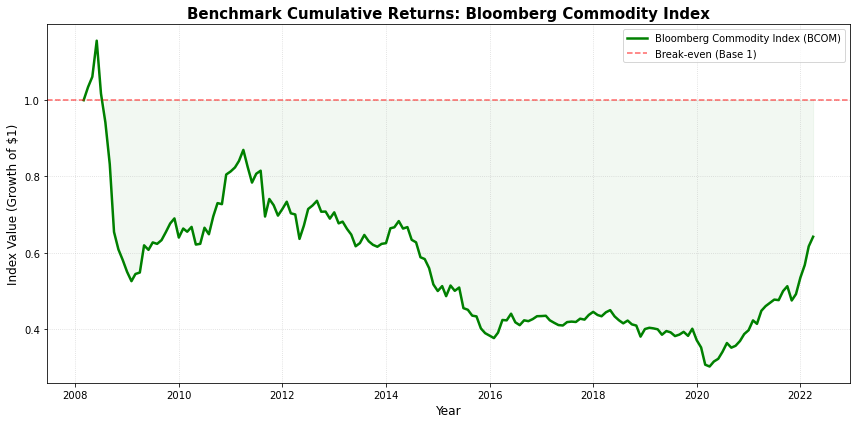

In [29]:
print('\nPlotting BCOM Index Growth assuming $1 as initial investment...')

# Ensure the benchmark curve starts at 1.0 for the plot
bcom_normalized = benchmark_equity / benchmark_equity.iloc[0]

# Plotting the BCOM curve
plt.figure(figsize=(12, 6))
plt.plot(benchmark_df['Date'], bcom_normalized.values, 
         linewidth=2.5, color='green', label='Bloomberg Commodity Index (BCOM)')

# Adding visual aids
plt.axhline(y=1, color='red', linestyle='--', alpha=0.6, label='Break-even (Base 1)')

# Shading the drawdown area to visualize value erosion
plt.fill_between(benchmark_df['Date'], 1, bcom_normalized.values, 
                 where=(bcom_normalized.values < 1), color='green', alpha=0.05)

# Format
plt.title('Benchmark Cumulative Returns: Bloomberg Commodity Index', fontsize=15, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Index Value (Growth of $1)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

---